# **Load and Prepare Dataset**

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Set plot style
plt.style.use('seaborn-v0_8')

# Load Auto MPG dataset
df = pd.read_csv('auto-mpg.csv', sep=',', 
                 names=['mpg', 'cylinders', 'displacement', 'horsepower', 
                        'weight', 'acceleration', 'model_year', 'origin', 'car_name'],
                 skiprows=1, na_values='?')  # Skip malformed header, handle '?' as NaN
# Drop 'car_name'
df = df.drop(columns=['car_name'])

# Convert numerical columns to float
num_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Add noise
np.random.seed(42)
for col in ['horsepower', 'weight', 'acceleration']:
    mask = np.random.rand(len(df)) < 0.05  # 5% missing
    df.loc[mask, col] = np.nan
for _ in range(3):  # Add 3 outliers
    row = np.random.randint(0, len(df))
    col = np.random.choice(['horsepower', 'weight', 'acceleration'])
    if not pd.isna(df.loc[row, col]):
        df.loc[row, col] *= 5

print("Dataset after adding noise:")
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())

# Bin 'mpg' for classification (custom thresholds for better interpretability)
bins = [0, 15, 25, df['mpg'].max()]  # Low: <15, Medium: 15-25, High: >25
labels = ['Low', 'Medium', 'High']
df['mpg_class'] = pd.cut(df['mpg'], bins=bins, labels=labels, include_lowest=True)
label_col = 'mpg_class'

Dataset after adding noise:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  

Missing Values:
mpg              0
cylinders        0
displacement     0
horsepower      32
weight          15
acceleration    22
model_year       0
origin           0
dtype: int64


# **Analyze Dataset**


--- Lab 1: Dataset Analysis ---
Preview:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin mpg_class  
0          70       1    Medium  
1          70       1       Low  
2          70       1    Medium  
3          70       1    Medium  
4          70       1    Medium  
Shape: (398, 9)
Data Types:
 mpg              float64
cylinders          int64
displacement     float64
horsepower       float64
weight           float64
acceleration     float64
model_year         int64
origin             int64
mpg_class       category
dtype: object
Dimensions: 398 rows, 9 columns
Label Column: mpg_class
Independe

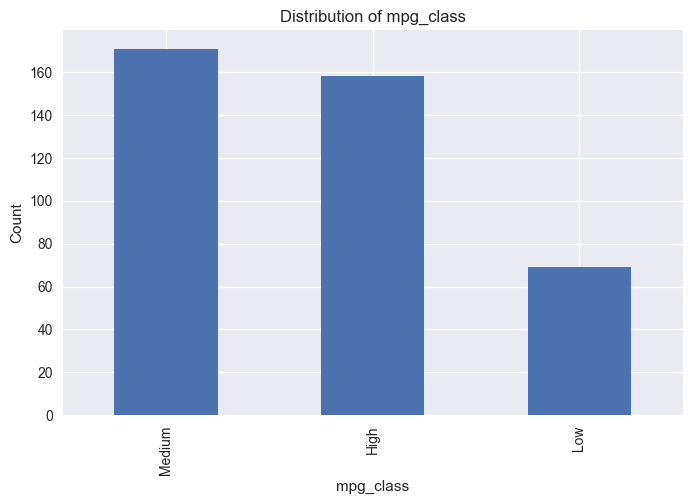

Problem Type: Multiclass Classification


In [45]:
def analyze_dataset(df, label_col='mpg_class'):
    print("\n--- Lab 1: Dataset Analysis ---")
    print("Preview:")
    print(df.head())
    print("Shape:", df.shape)
    print("Data Types:\n", df.dtypes)
    rows, cols = df.shape
    print(f"Dimensions: {rows} rows, {cols} columns")
    print(f"Label Column: {label_col}")
    independent_vars = [col for col in df.columns if col not in [label_col, 'mpg']]
    print(f"Independent Variables: {independent_vars}")
    print(f"Dependent Variable: {label_col}")
    X = df[independent_vars]
    y = df[label_col]
    print("\nFeatures Shape:", X.shape)
    print("Labels Shape:", y.shape)
    print("Unique Labels:", y.nunique())
    print("Labels:", y.unique())
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)
    print("Training Samples:", len(y_train))
    print("Validation Samples:", len(y_val))
    print("Test Samples:", len(y_test))
    plt.figure(figsize=(8, 5))
    y.value_counts().plot(kind='bar')
    plt.title(f'Distribution of {label_col}')
    plt.xlabel(label_col)
    plt.ylabel('Count')
    plt.show()
    problem_type = "Multiclass Classification"
    print(f"Problem Type: {problem_type}")

analyze_dataset(df)

# **Data Preprocessing**

In [47]:
print("\n--- Lab 2: Data Preprocessing ---")
print("Missing Values before:")
print(df.isnull().sum())
# Handle missing values
for col in ['horsepower', 'weight', 'acceleration']:
    df[col] = df[col].fillna(df[col].median())
# Handle outliers (cap at 1.5*IQR)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
print("Missing Values after:")
print(df.isnull().sum())
# Encode 'origin'
df = pd.get_dummies(df, columns=['origin'], prefix='origin')
# Scale numerical features
num_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
scaler = StandardScaler()
df[[col + '_Std' for col in num_cols]] = scaler.fit_transform(df[num_cols])
# Similarity measures
data = df[num_cols].values
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print("\nCosine Similarity (first 5x5):")
cosine_matrix = np.array([[cosine_sim(data[i], data[j]) for j in range(5)] for i in range(5)])
print(cosine_matrix)
def euc_dist(a, b):
    return np.linalg.norm(a - b)

print("\nEuclidean Distance (first 5x5):")
euc_matrix = np.array([[euc_dist(data[i], data[j]) for j in range(5)] for i in range(5)]) 
print(euc_matrix)

basket = (df[num_cols] > df[num_cols].median()).astype(int).values

def jaccard(a, b):
    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return intersection / union if union != 0 else 1.0

print("\nJaccard Similarity (first 5x5):")
# Line 38 Correction: Added the missing closing square bracket ']'
jaccard_matrix = np.array([[jaccard(basket[i], basket[j]) for j in range(5)] for i in range(5)])
print(jaccard_matrix)
print("Processed Preview:")
print(df.head())
# Save processed dataset
df.to_csv('auto-mpg_processed.csv', index=False)
print("\nProcessed dataset saved as 'auto-mpg_processed.csv'.")


--- Lab 2: Data Preprocessing ---
Missing Values before:
mpg              0
cylinders        0
displacement     0
horsepower      32
weight          15
acceleration    22
model_year       0
origin           0
mpg_class        0
dtype: int64
Missing Values after:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg_class       0
dtype: int64

Cosine Similarity (first 5x5):
[[1.         0.99994607 0.99996683 0.99997802 0.99999385]
 [0.99994607 1.         0.99999605 0.99997943 0.99996541]
 [0.99996683 0.99999605 1.         0.99999211 0.99998319]
 [0.99997802 0.99997943 0.99999211 1.         0.99999467]
 [0.99999385 0.99996541 0.99998319 0.99999467 1.        ]]

Euclidean Distance (first 5x5):
[[  0.         196.96509843  71.73562574  73.8241153   56.14490182]
 [196.96509843   0.         259.41906252 264.46408074 249.93199075]
 [ 71.73562574 259.41906252   0.          14.35270009  22.91833327]
 

# **Exploratory Data Analysis**


--- Lab 3: Exploratory Data Analysis ---


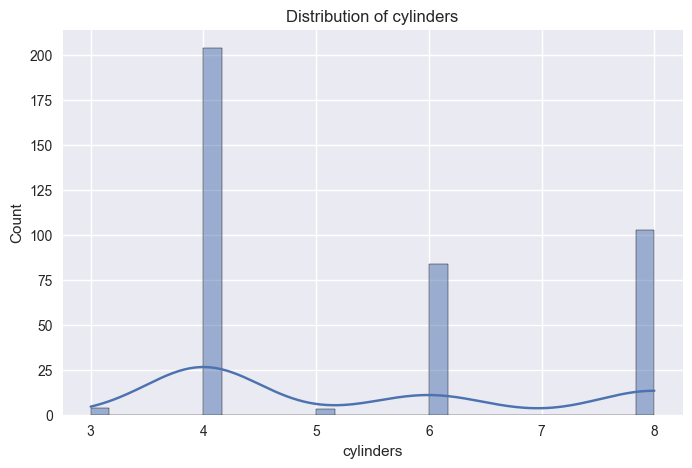

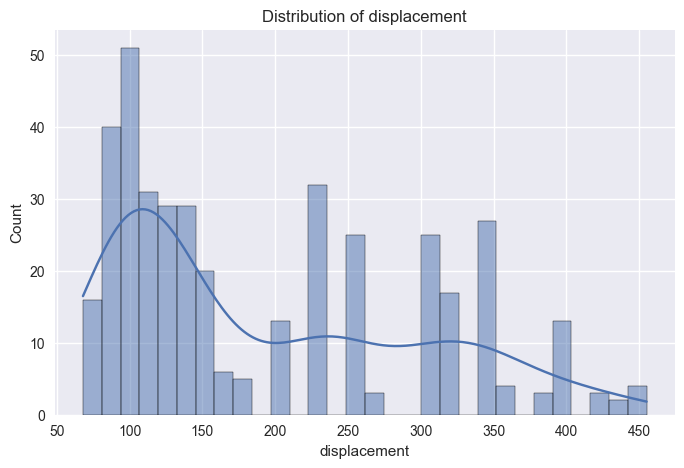

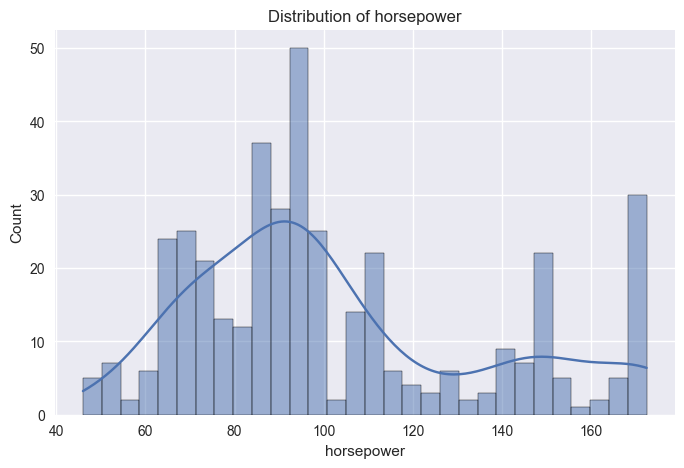

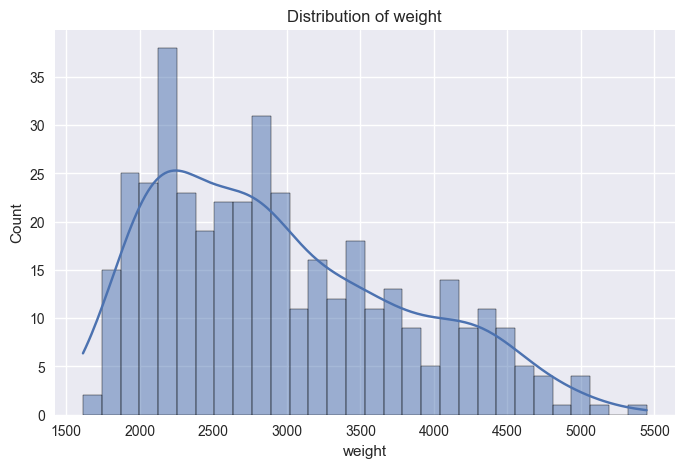

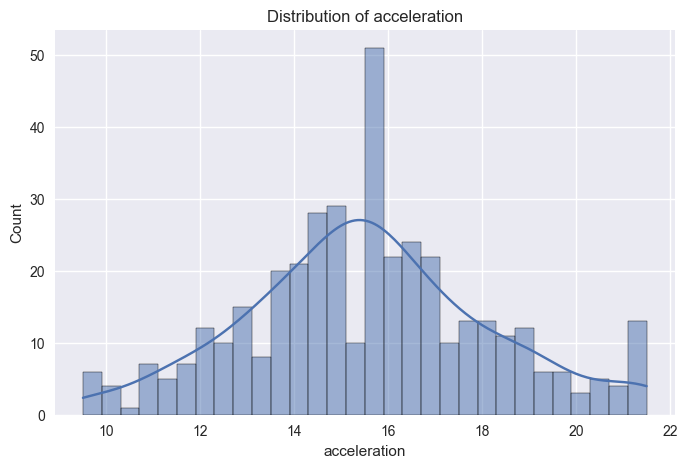

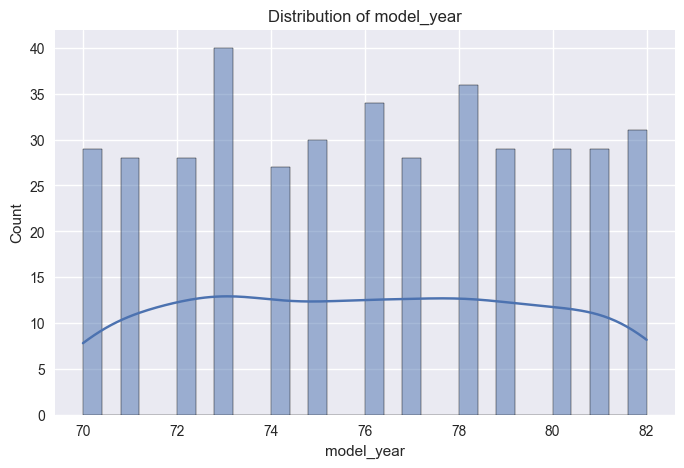

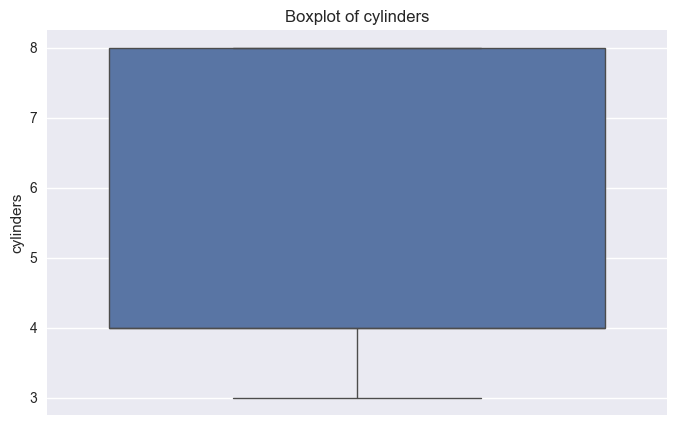

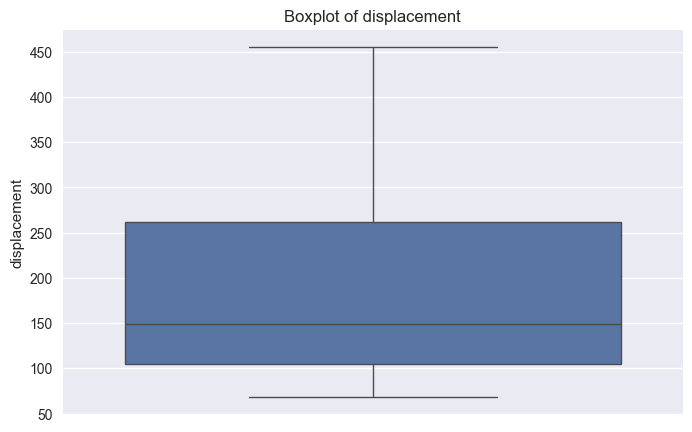

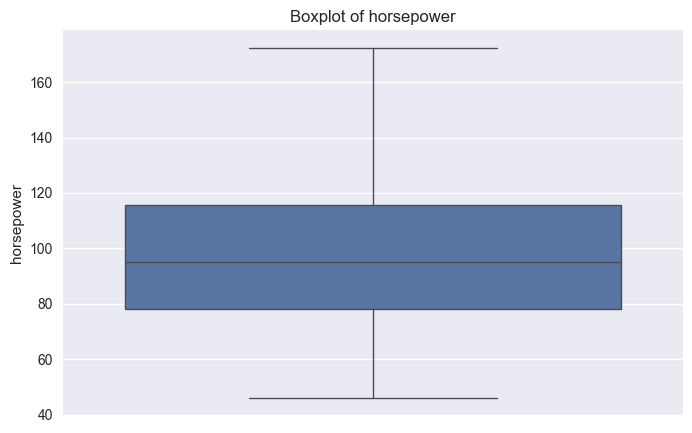

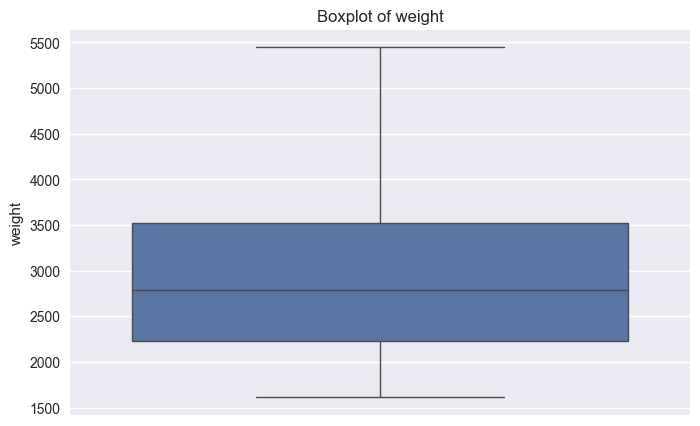

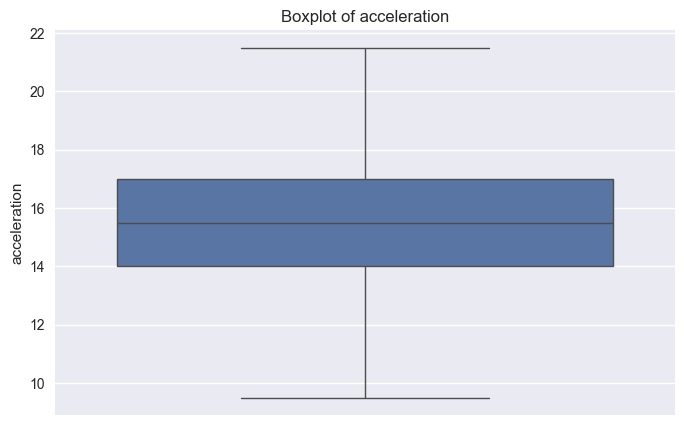

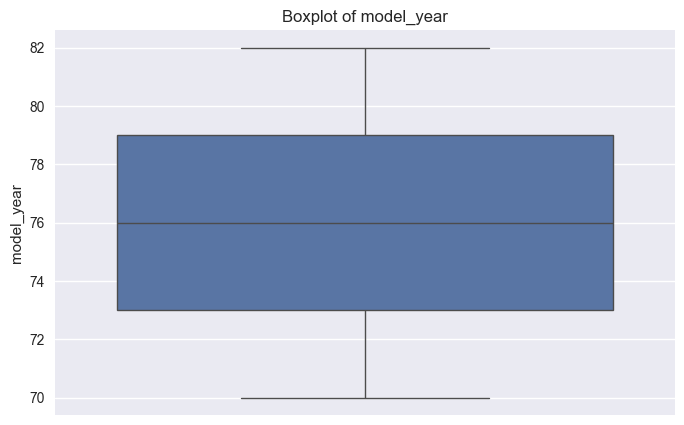

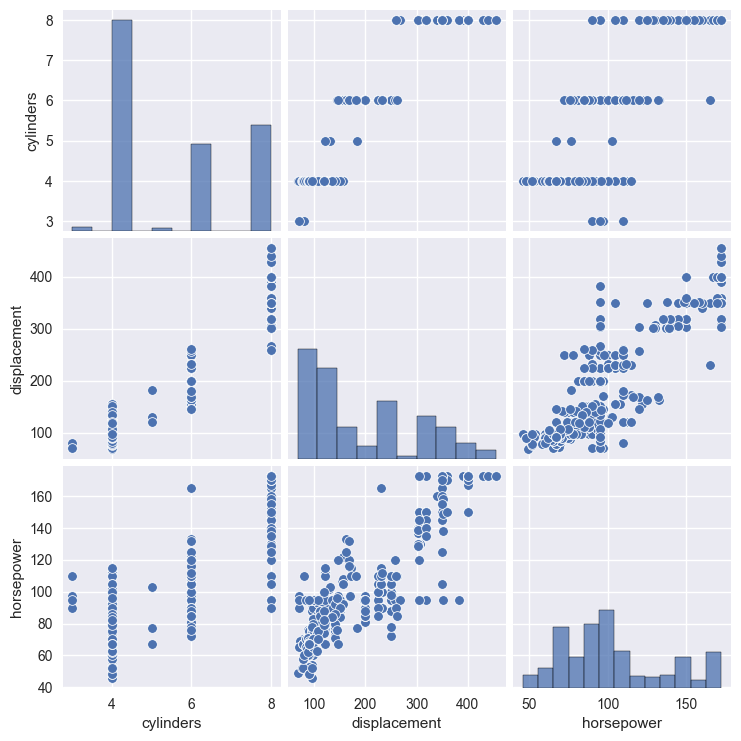


Pairwise Correlation Matrix:
              cylinders  displacement  horsepower    weight  acceleration  \
cylinders      1.000000      0.950721    0.835179  0.845753     -0.486497   
displacement   0.950721      1.000000    0.869085  0.885469     -0.528539   
horsepower     0.835179      0.869085    1.000000  0.807153     -0.639899   
weight         0.845753      0.885469    0.807153  1.000000     -0.349435   
acceleration  -0.486497     -0.528539   -0.639899 -0.349435      1.000000   
model_year    -0.348746     -0.370164   -0.386675 -0.296534      0.295759   

              model_year  
cylinders      -0.348746  
displacement   -0.370164  
horsepower     -0.386675  
weight         -0.296534  
acceleration    0.295759  
model_year      1.000000  


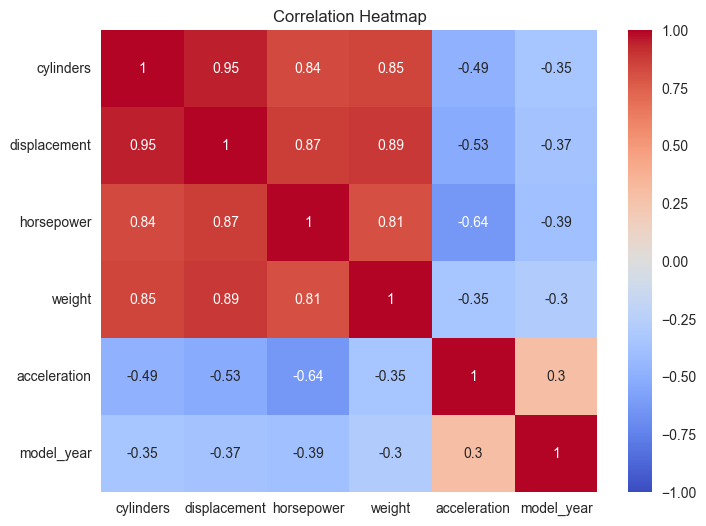

In [48]:
df = pd.read_csv('auto-mpg_processed.csv')
print("\n--- Lab 3: Exploratory Data Analysis ---")
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
# Pair plot for key features
sns.pairplot(df[num_cols[:3]])  # Limited to first 3 for clarity
plt.show()
print("\nPairwise Correlation Matrix:")
corr_matrix = df[num_cols].corr(method='pearson')
print(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

# **Classification with Decision Trees**


--- Lab 5: Classification ---
Test Accuracy (Entropy): 0.8125
Classification Report (Entropy):
              precision    recall  f1-score   support

        High       0.75      0.89      0.81        27
         Low       0.86      0.86      0.86        14
      Medium       0.85      0.74      0.79        39

    accuracy                           0.81        80
   macro avg       0.82      0.83      0.82        80
weighted avg       0.82      0.81      0.81        80


Feature Importance (Entropy):
displacement    0.417736
horsepower      0.214265
model_year      0.200859
weight          0.094355
acceleration    0.044877
cylinders       0.012374
origin_1        0.008346
origin_2        0.007190
origin_3        0.000000
dtype: float64


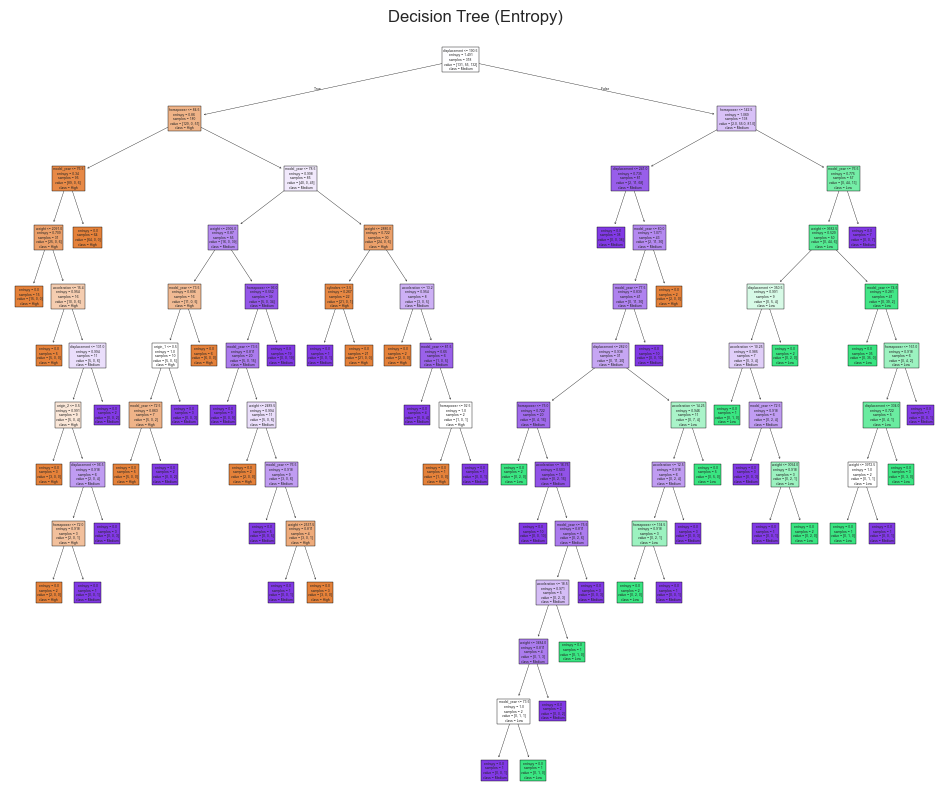

Test Accuracy (Gini): 0.8
Classification Report (Gini):
              precision    recall  f1-score   support

        High       0.72      0.85      0.78        27
         Low       0.86      0.86      0.86        14
      Medium       0.85      0.74      0.79        39

    accuracy                           0.80        80
   macro avg       0.81      0.82      0.81        80
weighted avg       0.81      0.80      0.80        80



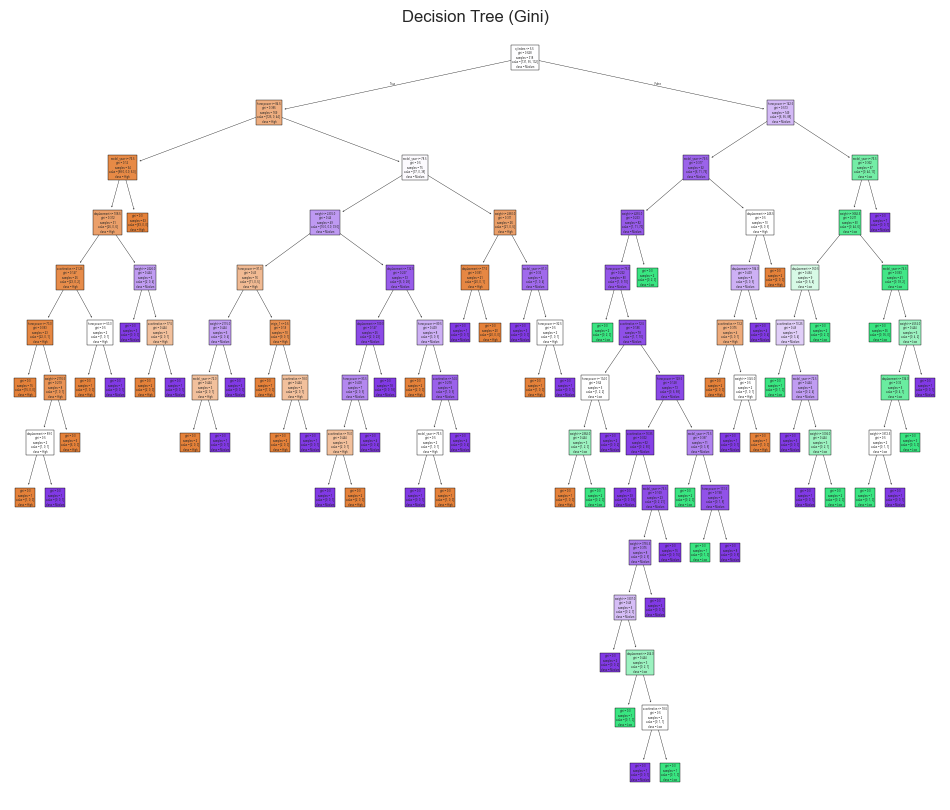

In [49]:
df = pd.read_csv('auto-mpg_processed.csv')
print("\n--- Lab 5: Classification ---")
X = df[num_cols + ['origin_1', 'origin_2', 'origin_3']]
y = df['mpg_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)
print("Test Accuracy (Entropy):", accuracy_score(y_test, y_pred_entropy))
print("Classification Report (Entropy):")
print(classification_report(y_test, y_pred_entropy))
# Feature importance
importances = pd.Series(dt_entropy.feature_importances_, index=X.columns)
print("\nFeature Importance (Entropy):")
print(importances.sort_values(ascending=False))
plt.figure(figsize=(12, 10))
plot_tree(dt_entropy, feature_names=X.columns, class_names=dt_entropy.classes_, filled=True)
plt.title('Decision Tree (Entropy)')
plt.show()
# Gini
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)
print("Test Accuracy (Gini):", accuracy_score(y_test, y_pred_gini))
print("Classification Report (Gini):")
print(classification_report(y_test, y_pred_gini))
plt.figure(figsize=(12, 10))
plot_tree(dt_gini, feature_names=X.columns, class_names=dt_gini.classes_, filled=True)
plt.title('Decision Tree (Gini)')
plt.show()

# **Clustering with k-Means and Hierarchical**


--- Lab 6: Clustering ---


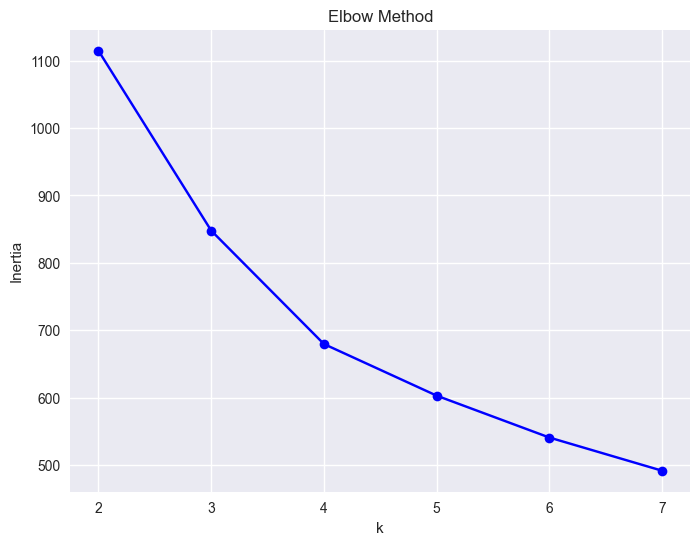

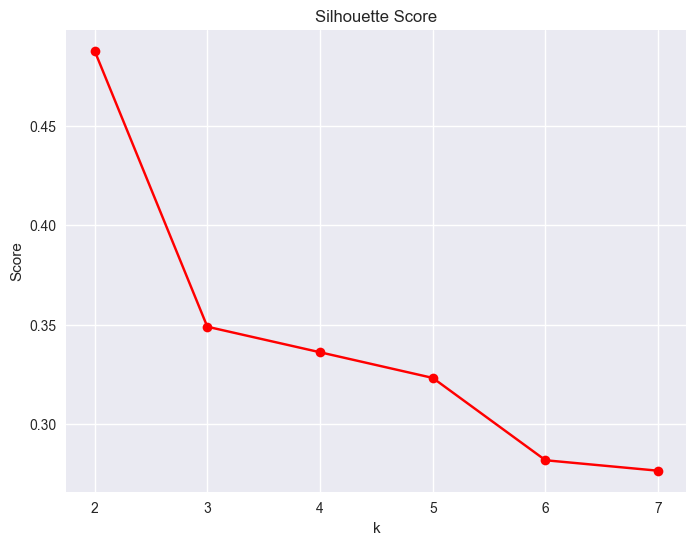

Silhouette Score for k=3: 0.34889435805000324


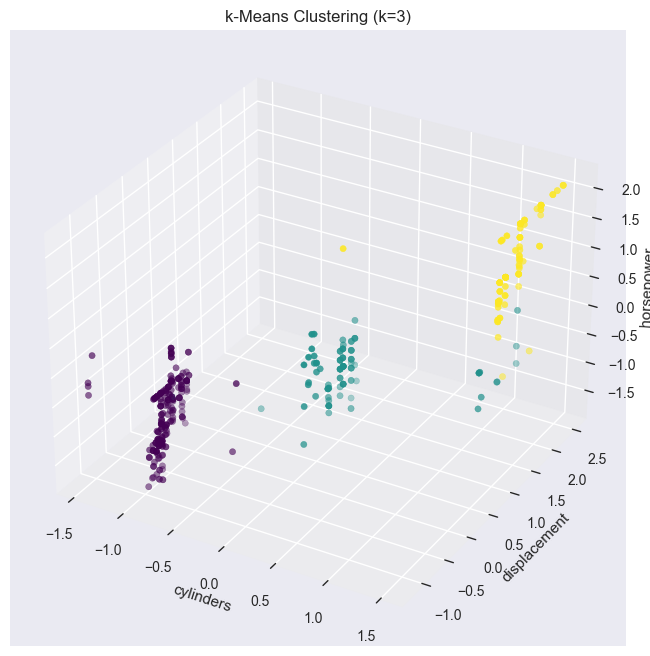

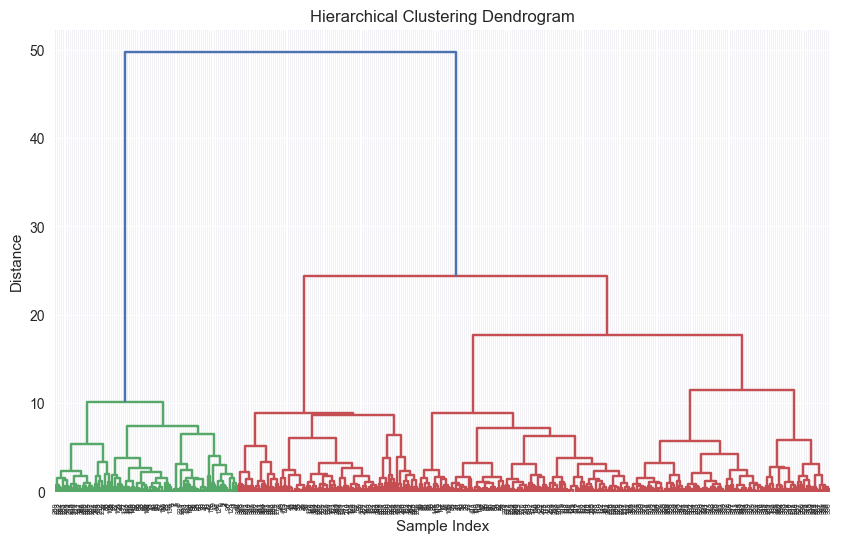

In [50]:
df = pd.read_csv('auto-mpg_processed.csv')
print("\n--- Lab 6: Clustering ---")
X = df[num_cols]
X_scaled = scaler.fit_transform(X)
inertia = []
silhouette_scores = []
K = range(2, 8)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()
plt.figure(figsize=(8, 6))
plt.plot(K, silhouette_scores, 'ro-')
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')
plt.show()
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
print("Silhouette Score for k=3:", silhouette_score(X_scaled, kmeans.labels_))
# 3D scatter plot for clustering
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=kmeans.labels_, cmap='viridis')
ax.set_xlabel(num_cols[0])
ax.set_ylabel(num_cols[1])
ax.set_zlabel(num_cols[2])
plt.title(f'k-Means Clustering (k={optimal_k})')
plt.show()
linkage_matrix = linkage(X_scaled, method='ward', metric='euclidean')
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()